In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

['test.csv', 'train.csv', 'gender_submission.csv']


In [2]:
train=pd.read_csv('../input/train.csv')
test=pd.read_csv('../input/test.csv')
print(train.info())
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Name           418 non-null object
Sex            418 non-null object
Age            332 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Ticket         418 non-null object
Fare           417 non-null 

In [3]:
#Extracting the last name of each passenger and storing it in a new column called 'LastName'
x=[]
for i in range(0,891):
    a=train['Name'][i].split(',')[0]
    x.append(a)
x=np.array(x)
train['LastName']=x
print('Unique values in "LastName" column of the training data are: ' + str(train['LastName'].nunique()))
print(train.info())

Unique values in "LastName" column of the training data are: 667
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
LastName       891 non-null object
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB
None


In [4]:
#'Ticket' column contains an optional Station code and ticket number.
#Extracting Station code and Ticket Number and stroing them in columns 'Station' & 'TicketNumber' respectively.
print(train['Ticket'].head())
Station=[]
TicketNumber=[]
for i in range(0,891):
    a=train['Ticket'][i].split()
    if len(a)==1:
        Station.append(np.nan)
        TicketNumber.append(a[0])
    elif len(a)==2:
        Station.append(a[0])
        TicketNumber.append(a[1])
    else:
        Station.append(a[0])
        TicketNumber.append(a[2])
train['Station']=np.array(Station)
train['TicketNumber']=np.array(TicketNumber)
train['Station'][train['Station']=='nan']=np.NaN
train['TicketNumber'][train['TicketNumber']=='LINE']=-1
train['Station'].fillna(np.NaN,inplace=True)
print(train.info())
print("The number of unique values in station are: " + str(train['Station'].nunique()))

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
PassengerId     891 non-null int64
Survived        891 non-null int64
Pclass          891 non-null int64
Name            891 non-null object
Sex             891 non-null object
Age             714 non-null float64
SibSp           891 non-null int64
Parch           891 non-null int64
Ticket          891 non-null object
Fare            891 non-null float64
Cabin           204 non-null object
Embarked        889 non-null object
LastName        891 non-null object
Station         226 non-null object
TicketNumber    891 non-null object
dtypes: float64(2), int64(5), object(8)
memory usage: 104.5+ KB
None
The number of unique values in station are: 42


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


In [5]:
#Checking info about the missing 2 missing values of 'Embarked' column
print(train[train['Embarked'].isnull()==True])
print(train[['Survived','Name','Age']][train['Embarked'].isnull()==True])

     PassengerId  Survived  Pclass      ...      LastName Station  TicketNumber
61            62         1       1      ...         Icard     NaN        113572
829          830         1       1      ...         Stone     NaN        113572

[2 rows x 15 columns]
     Survived                                       Name   Age
61          1                        Icard, Miss. Amelie  38.0
829         1  Stone, Mrs. George Nelson (Martha Evelyn)  62.0


In [6]:
#Icard was Mrs.Nelson's maid, this means their embarked port is same. Let's find out!
#A quick google search tells us that their embarkation port was Southampton i.e, 'S'. It also tells us that their cabin was B-28.
train['Embarked'].fillna('S',inplace=True)
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
PassengerId     891 non-null int64
Survived        891 non-null int64
Pclass          891 non-null int64
Name            891 non-null object
Sex             891 non-null object
Age             714 non-null float64
SibSp           891 non-null int64
Parch           891 non-null int64
Ticket          891 non-null object
Fare            891 non-null float64
Cabin           204 non-null object
Embarked        891 non-null object
LastName        891 non-null object
Station         226 non-null object
TicketNumber    891 non-null object
dtypes: float64(2), int64(5), object(8)
memory usage: 104.5+ KB
None


In [7]:
#Extracting Cabin type(A,B,C,D,E,F,G) from Cabin and storing it in Cabin again
print(train['Cabin'].head(10))
train['Cabin']=train['Cabin'].str.extract('([A-Z])',expand=True)
#Fill the missing cabin values with 'U'
train['Cabin'].fillna('U',inplace=True)
print(train['Cabin'].head(10))
print(train.info())

0     NaN
1     C85
2     NaN
3    C123
4     NaN
5     NaN
6     E46
7     NaN
8     NaN
9     NaN
Name: Cabin, dtype: object
0    U
1    C
2    U
3    C
4    U
5    U
6    E
7    U
8    U
9    U
Name: Cabin, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
PassengerId     891 non-null int64
Survived        891 non-null int64
Pclass          891 non-null int64
Name            891 non-null object
Sex             891 non-null object
Age             714 non-null float64
SibSp           891 non-null int64
Parch           891 non-null int64
Ticket          891 non-null object
Fare            891 non-null float64
Cabin           891 non-null object
Embarked        891 non-null object
LastName        891 non-null object
Station         226 non-null object
TicketNumber    891 non-null object
dtypes: float64(2), int64(5), object(8)
memory usage: 104.5+ KB
None


/opt/conda/lib/python3.6/site-packages/numpy/lib/histograms.py:824: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/opt/conda/lib/python3.6/site-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)
/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


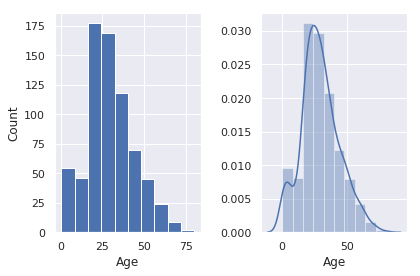

In [8]:
#Histogram and distplot of 'Age'
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
plt.subplot(1,2,1)
plt.hist(train['Age'],bins=10)
plt.xlabel('Age')
plt.ylabel('Count')
plt.subplot(1,2,2)
sns.distplot(train['Age'][train['Age'].isnull()==False],bins=10)
plt.tight_layout()
#The graph is negatively skewed

In [9]:
#Filling the missing 'Age' values with random integers between (mean-std,mean+std) of 'Age'
train['Age'].fillna(np.random.randint(train['Age'].mean()-train['Age'].std(),train['Age'].mean()+train['Age'].std()),inplace=True)
#train['Family']=train['Parch']+train['SibSp']+1
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
PassengerId     891 non-null int64
Survived        891 non-null int64
Pclass          891 non-null int64
Name            891 non-null object
Sex             891 non-null object
Age             891 non-null float64
SibSp           891 non-null int64
Parch           891 non-null int64
Ticket          891 non-null object
Fare            891 non-null float64
Cabin           891 non-null object
Embarked        891 non-null object
LastName        891 non-null object
Station         226 non-null object
TicketNumber    891 non-null object
dtypes: float64(2), int64(5), object(8)
memory usage: 104.5+ KB
None


In [10]:
#Encoding columns
to_drop=['Name','Ticket','Station','TicketNumber','PassengerId','LastName']#'Parch','SibSp'
to_int=['TicketNumber']
to_cat=['Sex','Cabin','Embarked','LastName']
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
for col in to_cat:
    train[col]=encoder.fit_transform(train[col])
train['TicketNumber']=train['TicketNumber'].astype(int)
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
PassengerId     891 non-null int64
Survived        891 non-null int64
Pclass          891 non-null int64
Name            891 non-null object
Sex             891 non-null int64
Age             891 non-null float64
SibSp           891 non-null int64
Parch           891 non-null int64
Ticket          891 non-null object
Fare            891 non-null float64
Cabin           891 non-null int64
Embarked        891 non-null int64
LastName        891 non-null int64
Station         226 non-null object
TicketNumber    891 non-null int64
dtypes: float64(2), int64(10), object(3)
memory usage: 104.5+ KB
None


In [11]:
#Create x_train by dropping the above tables
x_train=train.drop(to_drop,axis=1)
x_train.drop('Survived',axis=1,inplace=True)
y_train=train['Survived']
print(x_train.info())
print(y_train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
Pclass      891 non-null int64
Sex         891 non-null int64
Age         891 non-null float64
SibSp       891 non-null int64
Parch       891 non-null int64
Fare        891 non-null float64
Cabin       891 non-null int64
Embarked    891 non-null int64
dtypes: float64(2), int64(6)
memory usage: 55.8 KB
None
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


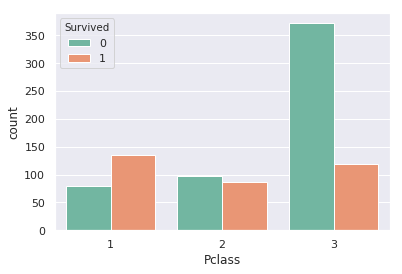

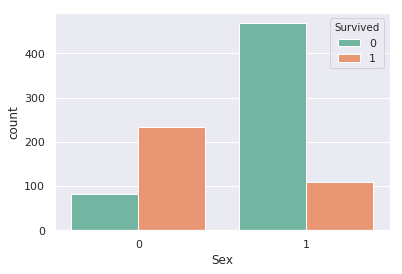

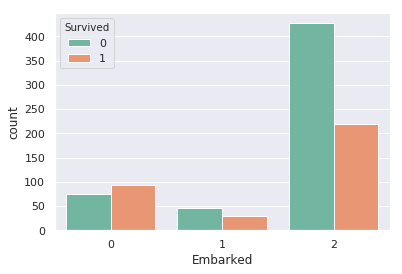

In [12]:
#Let's visualise our data
cols=['Pclass','Sex','Embarked']#'Family'
for col in cols:
    sns.countplot(train[col],hue=train['Survived'],palette="Set2")
    plt.show()
#Conclusion from these plot - Survival rate of females are much more than male, survival rate is very high in Pclass 3 and for people who embarked from '2'

In [13]:
#Cleaning the test data
test['Cabin']=test['Cabin'].str.extract('([A-Z])',expand=True)
test['Cabin'].fillna('U',inplace=True)
print(test[['Pclass','Cabin','Embarked']][test['Fare'].isnull()==True])
med=test['Fare'][np.logical_and(test['Pclass']==3,np.logical_and(test['Cabin']=='U',test['Embarked']=='S'))].median()
print("The median of Fare where Pclass, Cabin and Embarked features matched is " + str(med))
test['Fare'].fillna(med,inplace=True)
test['Age'].fillna(np.random.randint(train['Age'].mean()-train['Age'].std(),train['Age'].mean()+train['Age'].std()),inplace=True)
print(test.info())

     Pclass Cabin Embarked
152       3     U        S
The median of Fare where Pclass, Cabin and Embarked features matched is 8.05
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Name           418 non-null object
Sex            418 non-null object
Age            418 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Ticket         418 non-null object
Fare           418 non-null float64
Cabin          418 non-null object
Embarked       418 non-null object
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB
None


In [14]:
x=[]
for i in range(0,418):
    a=test['Name'][i].split(',')[0]
    x.append(a)
x=np.array(x)
test['LastName']=x
#test['Family']=test['Parch']+test['SibSp']+1
for col in to_cat:
    test[col]=encoder.fit_transform(test[col])
print(test.info())
print(test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Name           418 non-null object
Sex            418 non-null int64
Age            418 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Ticket         418 non-null object
Fare           418 non-null float64
Cabin          418 non-null int64
Embarked       418 non-null int64
LastName       418 non-null int64
dtypes: float64(2), int64(8), object(2)
memory usage: 39.3+ KB
None
   PassengerId  Pclass    ...    Embarked  LastName
0          892       3    ...           1       172
1          893       3    ...           2       339
2          894       2    ...           1       231
3          895       3    ...           2       344
4          896       3    ...           2       150

[5 rows x 12 columns]


In [15]:
to_drop=['Name','Ticket','PassengerId','LastName']#'SibSp','Parch'
x_test=test.drop(to_drop,axis=1)
print(x_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
Pclass      418 non-null int64
Sex         418 non-null int64
Age         418 non-null float64
SibSp       418 non-null int64
Parch       418 non-null int64
Fare        418 non-null float64
Cabin       418 non-null int64
Embarked    418 non-null int64
dtypes: float64(2), int64(6)
memory usage: 26.2 KB
None


In [16]:
#Tried xgb, LogisticRegression and DecisionTreeClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
model=xgb.XGBClassifier()#Keep an eye on hyper-parameters
modelL=LogisticRegression()
modelDTC=DecisionTreeClassifier()
model.fit(x_train,y_train)
modelL.fit(x_train,y_train)
modelDTC.fit(x_train,y_train)
print("Score on training data for xgbclassifier is around " + str(int(model.score(x_train,y_train)*100)) + "%")
print("Score on training data for LogisticRegression is around " + str(int(modelL.score(x_train,y_train)*100)) + "%")
print("Score on training data for DecisionTreeClassifier is around " + str(int(modelDTC.score(x_train,y_train)*100)) + "%")

Score on training data for xgbclassifier is around 87%
Score on training data for LogisticRegression is around 80%
Score on training data for DecisionTreeClassifier is around 98%


/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


In [17]:
#Going ahead with xgb
y_test=model.predict(x_test)
ans=pd.DataFrame({'PassengerId':test['PassengerId'],'Survived':y_test})
ans.to_csv('outputxgb.csv',index=False)